# Лабораторная работа №6: Алгоритм Дейкстры и Флойда.

Лабораторная работа состоит из 6 задач. Для каждой задачи вы должны дать: \
1) код, где первый комментарий - асимптотическая сложность алгоритма (по времени и по памяти!) \

2) скрин с окнутой задачей из тестирующей системы\

3) ВАШЕ (не гпт) описание работы (так называемая, интуиция / идея решения).

Задача засчитывается, если три пункта выполнены честно.

Если вдруг, обнаружится плагиат / гпт решения - аннулируется задача без возможности апелляции.

# Приступим


## Задача: самый короткий путь ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=32&id_topic=52&id_problem=1024)) [1 балл]

Дан ориентированный взвешенный полный граф, рёбрам которого приписаны некоторые веса (длины). Веса могут быть положительными, отрицательными или равными нулю. Нас интересует минимум длин всех возможных путей между всеми парами различных вершин графа. Необходимо выяснить, существует ли этот минимум, и, если существует, вычислить его. (Минимум не существует, если в графе можно найти путь отрицательной длины, сколь угодно большой по модулю).

---

## Входные данные

- В первой строке входного файла `INPUT.TXT` записано одно целое число N (3 ≤ N ≤ 50) — количество вершин графа.
- Далее следует матрица смежности из N строк, каждая из которых содержит N целых чисел. j-ое число в i-ой строке задаёт длину ребра, ведущего из i-й вершины в j-ую. Все значения не превосходят по модулю 10^6. На главной диагонали матрицы стоят нули.

---

## Выходные данные

В выходной файл `OUTPUT.TXT` выведите одно число — искомый минимум длин между всеми парами различных вершин. Если минимум не существует, выведите -1.

---

## Примеры

### Пример 1

**Входные данные:**
```
3
0 42 18468
6335 0 26501
19170 15725 0
```

**Выходные данные:**
```
42
```

### Пример 2

**Входные данные:**
```
3
0 -7 3
-2 0 10
2 215 0
```

**Выходные данные:**
```
-1
```

In [ ]:
# Асимптотическая сложность по времени — O(N^3)
# Асимптотическая сложность по памяти — O(N^2)


# ВАШ КОД
n = int(input())
dist = [list(map(int, input().split())) for _ in range(n)]

# Алгоритм Флойда-Уоршелла
for k in range(n):
    for i in range(n):
        for j in range(n):
            if dist[i][k] + dist[k][j] < dist[i][j]:
                dist[i][j] = dist[i][k] + dist[k][j]

# Проверка на отрицательные циклы
for i in range(n):
    if dist[i][i] < 0:
        print("-1", end='')
        exit()

# Минимум среди всех пар i ≠ j
result = min(dist[i][j] for i in range(n) for j in range(n) if i != j)
print(result, end='')



### ВАША интуиция
Идея — с помощью алгоритма Флойда–Уоршелла найти кратчайшие пути между всеми парами и проверить наличие отрицательных циклов.

### ВАШ скрин ОКнутой задачи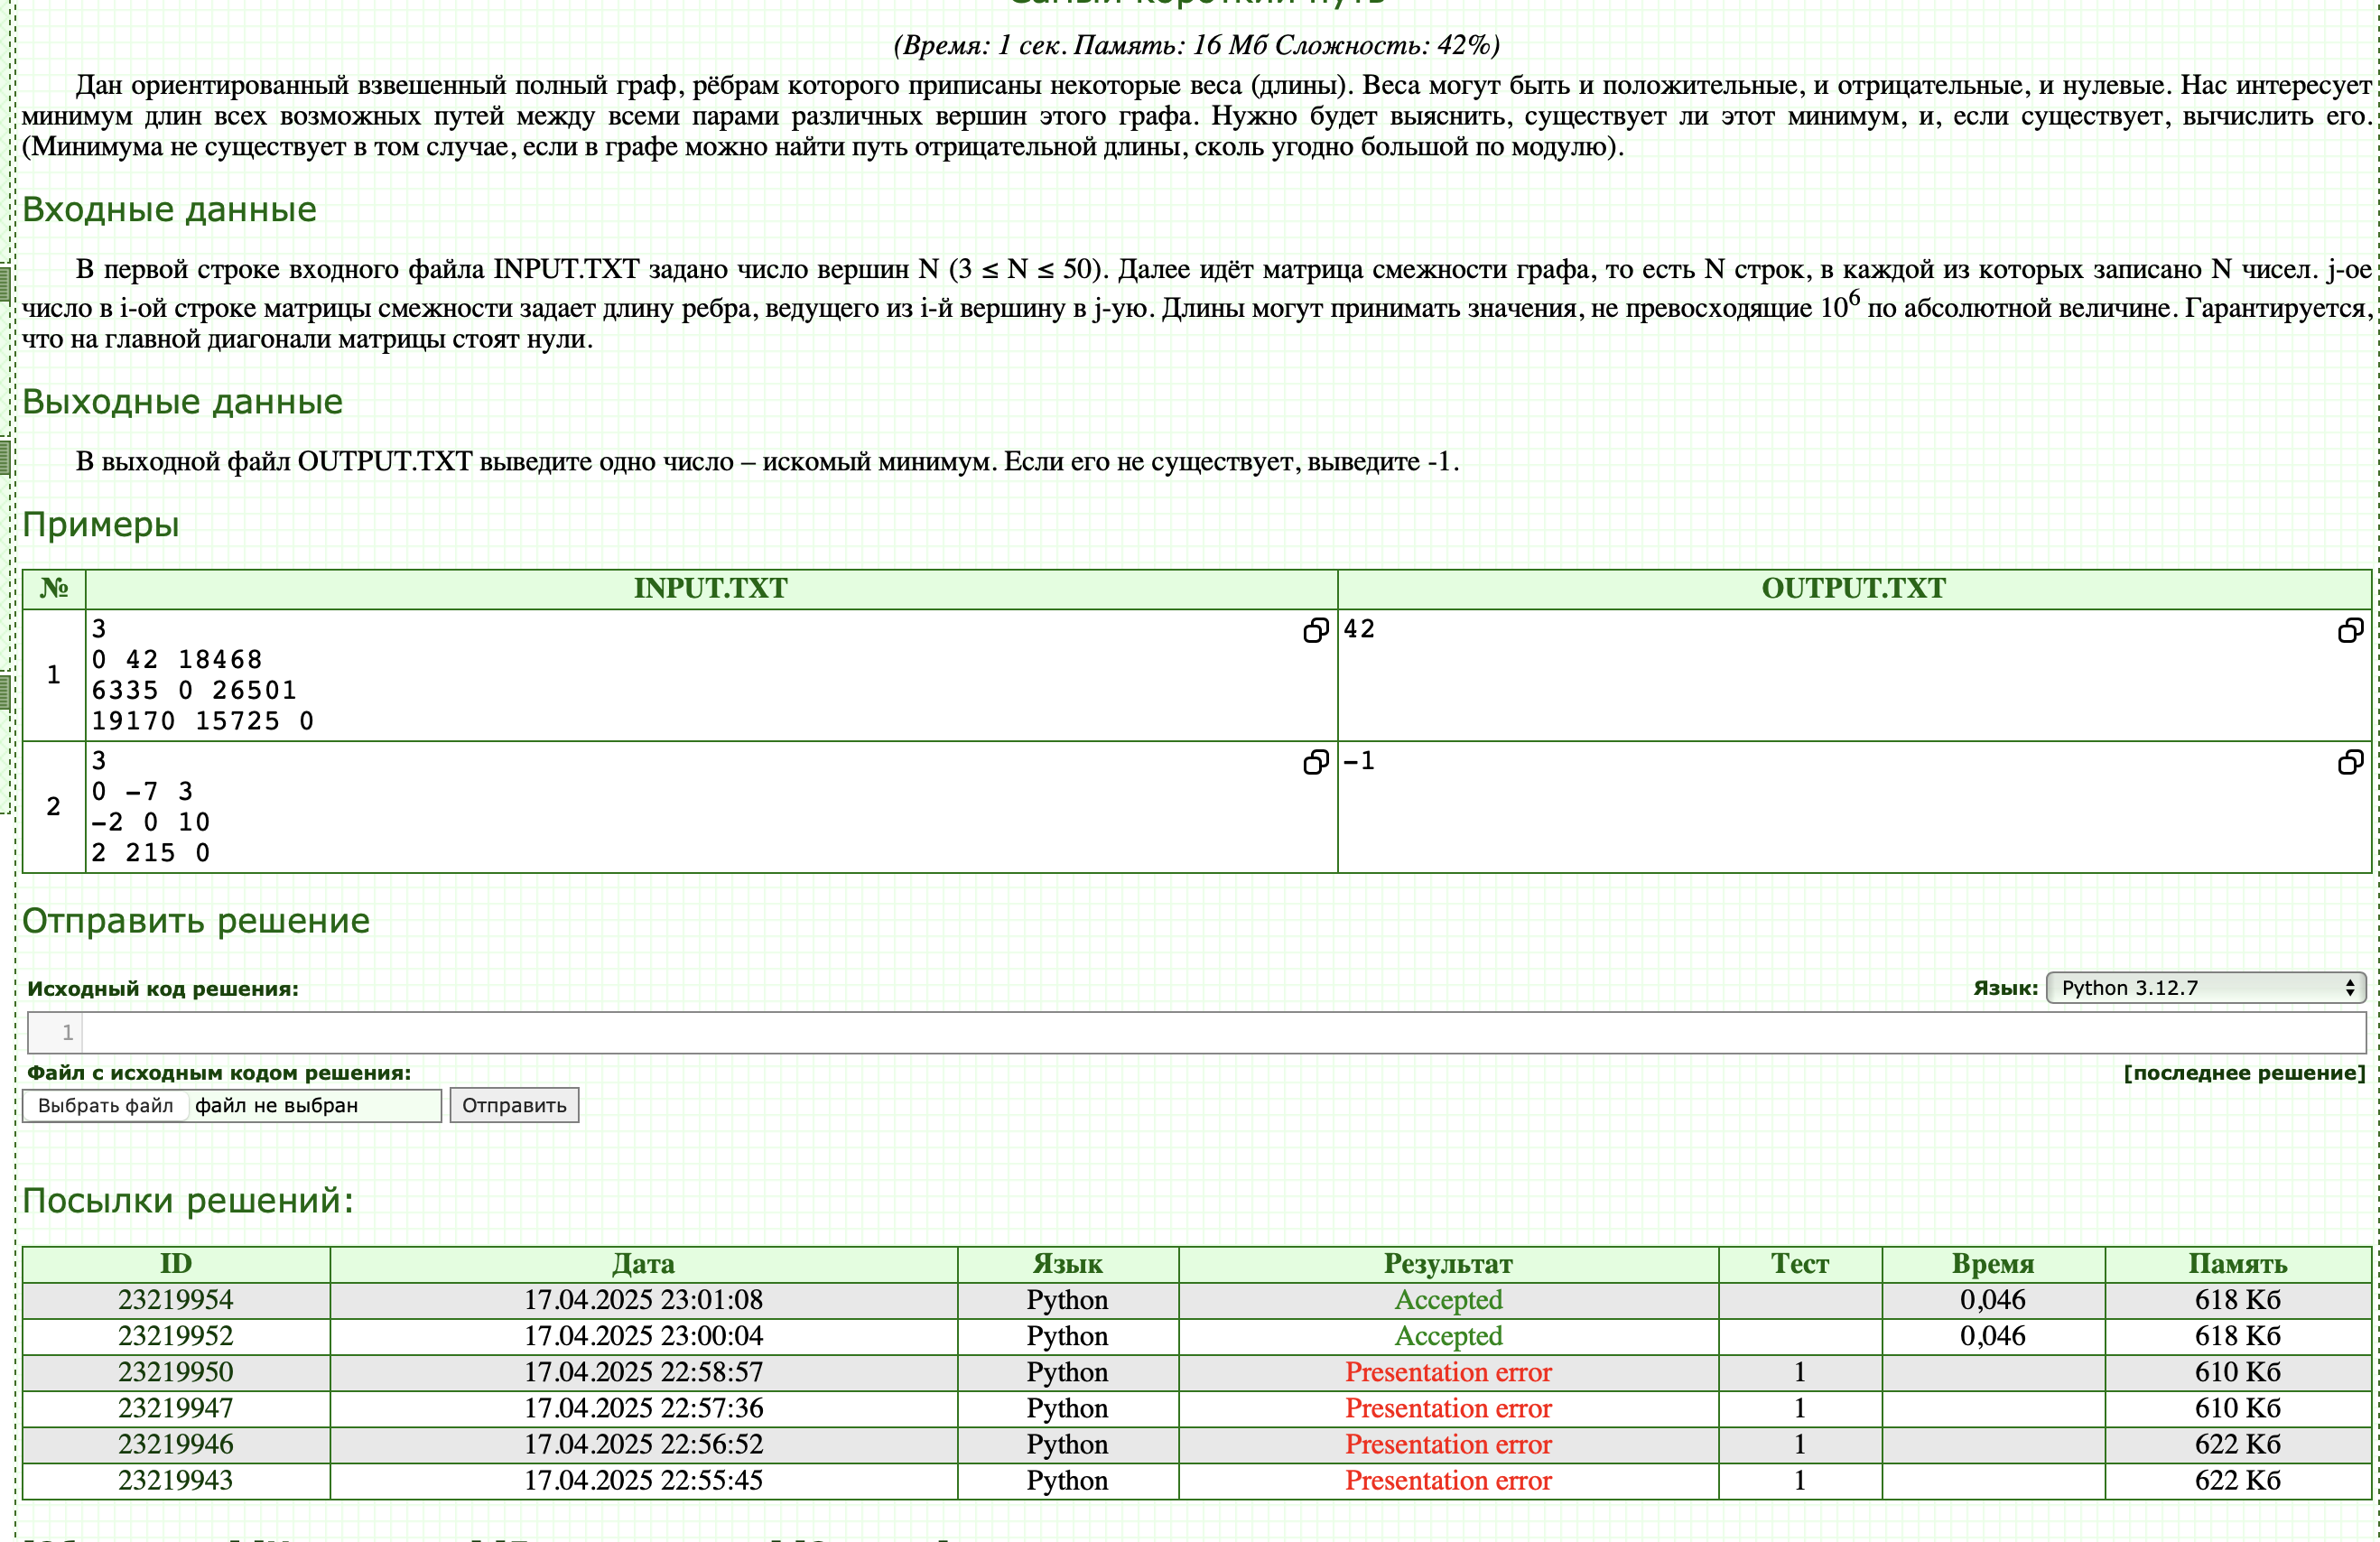

## Задача: Транзитивное замыкание ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=32&id_topic=52&id_problem=1026)) [1 балл]

Невзвешенный ориентированный граф задан своей матрицей смежности. Требуется построить его транзитивное замыкание, то есть матрицу, в которой в i-й строке и j-м столбце находится **1**, если существует путь (возможно, через промежуточные вершины) от вершины **i** к вершине **j**, и **0** – иначе.

---

## Входные данные

- В первой строке входного файла `INPUT.TXT` записано целое число **N** (1 ≤ N ≤ 100) – число вершин в графе.
- Далее следует матрица смежности из **N** строк, каждая из которых содержит **N** чисел **0** или **1**. Гарантируется, что на главной диагонали матрицы стоят единицы.

---

## Выходные данные

В выходной файл `OUTPUT.TXT` выведите матрицу транзитивного замыкания графа в том же формате, что и матрица смежности.

---

## Пример

### Пример 1

**Входные данные:**
```
4
1 1 0 0
0 1 1 0
1 0 1 0
0 0 1 1
```

**Выходные данные:**
```
1 1 1 0
1 1 1 0
1 1 1 0
1 1 1 1
```

In [ ]:
# Асимптотическая сложность по времени — O(N^3)
# Асимптотическая сложность по памяти — O(N^2)

n = int(input())
g = [list(map(int, input().split())) for _ in range(n)]

# Флойд–Уоршелл по достижимости
for k in range(n):
    for i in range(n):
        for j in range(n):
            if g[i][k] and g[k][j]:
                g[i][j] = 1

# Печатаем результат без \n в конце!
for i in range(n):
    row = ' '.join(map(str, g[i]))
    if i != n - 1:
        print(row)
    else:
        print(row, end='')


### ВАША интуиция
Используем булевый Флойд–Уоршелл, чтобы отметить достижимость всех вершин через промежуточные пути.

### ВАШ скрин ОКнутой задачи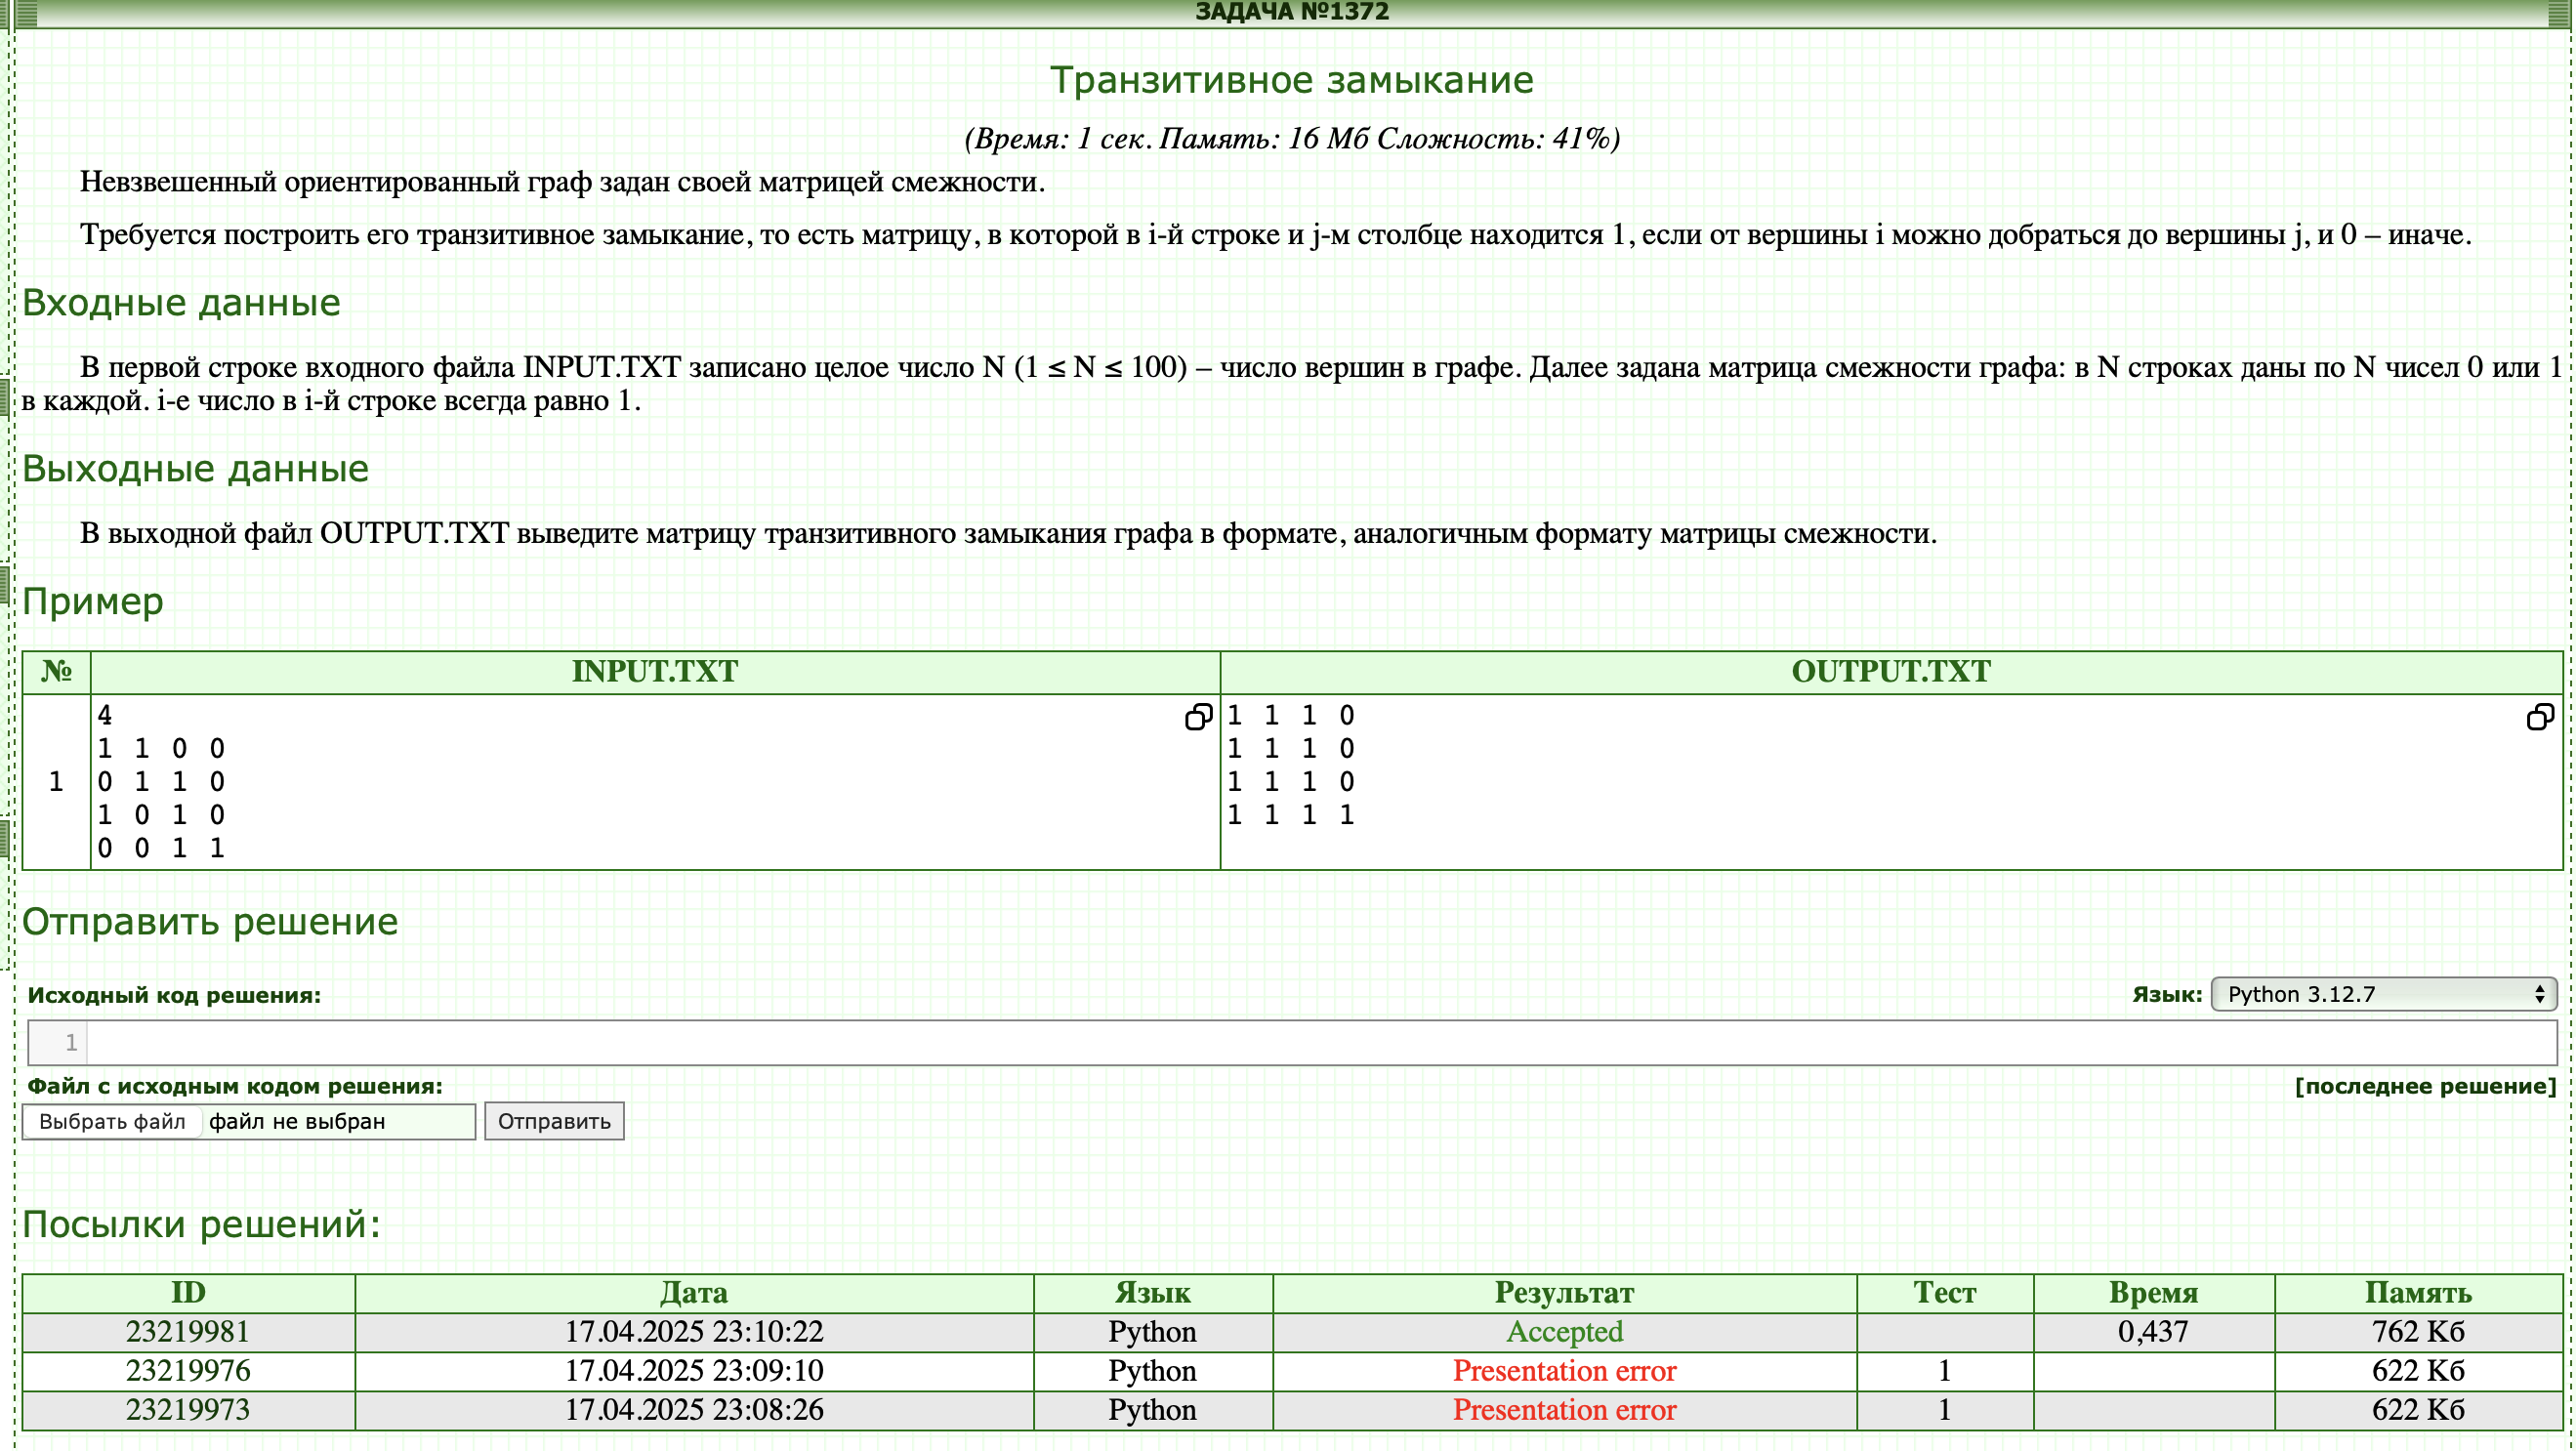

## Задача: два профессора ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=32&id_topic=52&id_problem=1027)) [0.5 балл]

Профессоры Флойд и Дейкстра требуют кабинеты в зданиях, расположенных как можно дальше друг от друга. Требуется найти такую пару зданий, кратчайший путь между которыми существует и является наибольшим среди всех возможных кратчайших путей между парами зданий. Необходимо вывести длину этого пути.

---

## Входные данные

- В первой строке входного файла `INPUT.TXT` записаны два целых числа **N** и **M** (1 ≤ N ≤ 100, 0 ≤ M ≤ N·(N−1)/2) — количество зданий и количество двунаправленных дорог между ними.
- Далее следуют **M** строк, каждая из которых содержит три целых числа: **si**, **ei**, **li** — номера зданий, соединённых дорогой, и длина этой дороги (1 ≤ si, ei ≤ N, 0 ≤ li ≤ 100). Дороги двусторонние.

---

## Выходные данные

В выходной файл `OUTPUT.TXT` выведите одно число — длину самого длинного из кратчайших путей между всеми парами зданий, между которыми существует путь. Если таких пар не существует (т.е. граф несвязный), выведите 0.

---

## Примеры

### Пример 1

**Входные данные:**
```
3 2
1 2 1
2 3 2
```

**Выходные данные:**
```
3
```

### Пример 2

**Входные данные:**
```
3 0
```

**Выходные данные:**
```
0
```

In [ ]:
# Асимптотическая сложность по времени — O(N^3)
# Асимптотическая сложность по памяти — O(N^2)

INF = 10**9

n, m = map(int, input().split())
dist = [[INF] * n for _ in range(n)]

# Инициализация расстояний
for i in range(n):
    dist[i][i] = 0

for _ in range(m):
    u, v, w = map(int, input().split())
    dist[u - 1][v - 1] = min(dist[u - 1][v - 1], w)
    dist[v - 1][u - 1] = min(dist[v - 1][u - 1], w)

# Флойд-Уоршелл
for k in range(n):
    for i in range(n):
        for j in range(n):
            if dist[i][k] + dist[k][j] < dist[i][j]:
                dist[i][j] = dist[i][k] + dist[k][j]

# Поиск самого длинного кратчайшего пути
max_dist = 0
for i in range(n):
    for j in range(n):
        if dist[i][j] < INF:
            max_dist = max(max_dist, dist[i][j])

print(max_dist, end='')


### ВАША интуиция
Строим матрицу расстояний с помощью алгоритма Флойда–Уоршелла, затем ищем максимум среди всех конечных кратчайших расстояний.

### ВАШ скрин ОКнутой задачи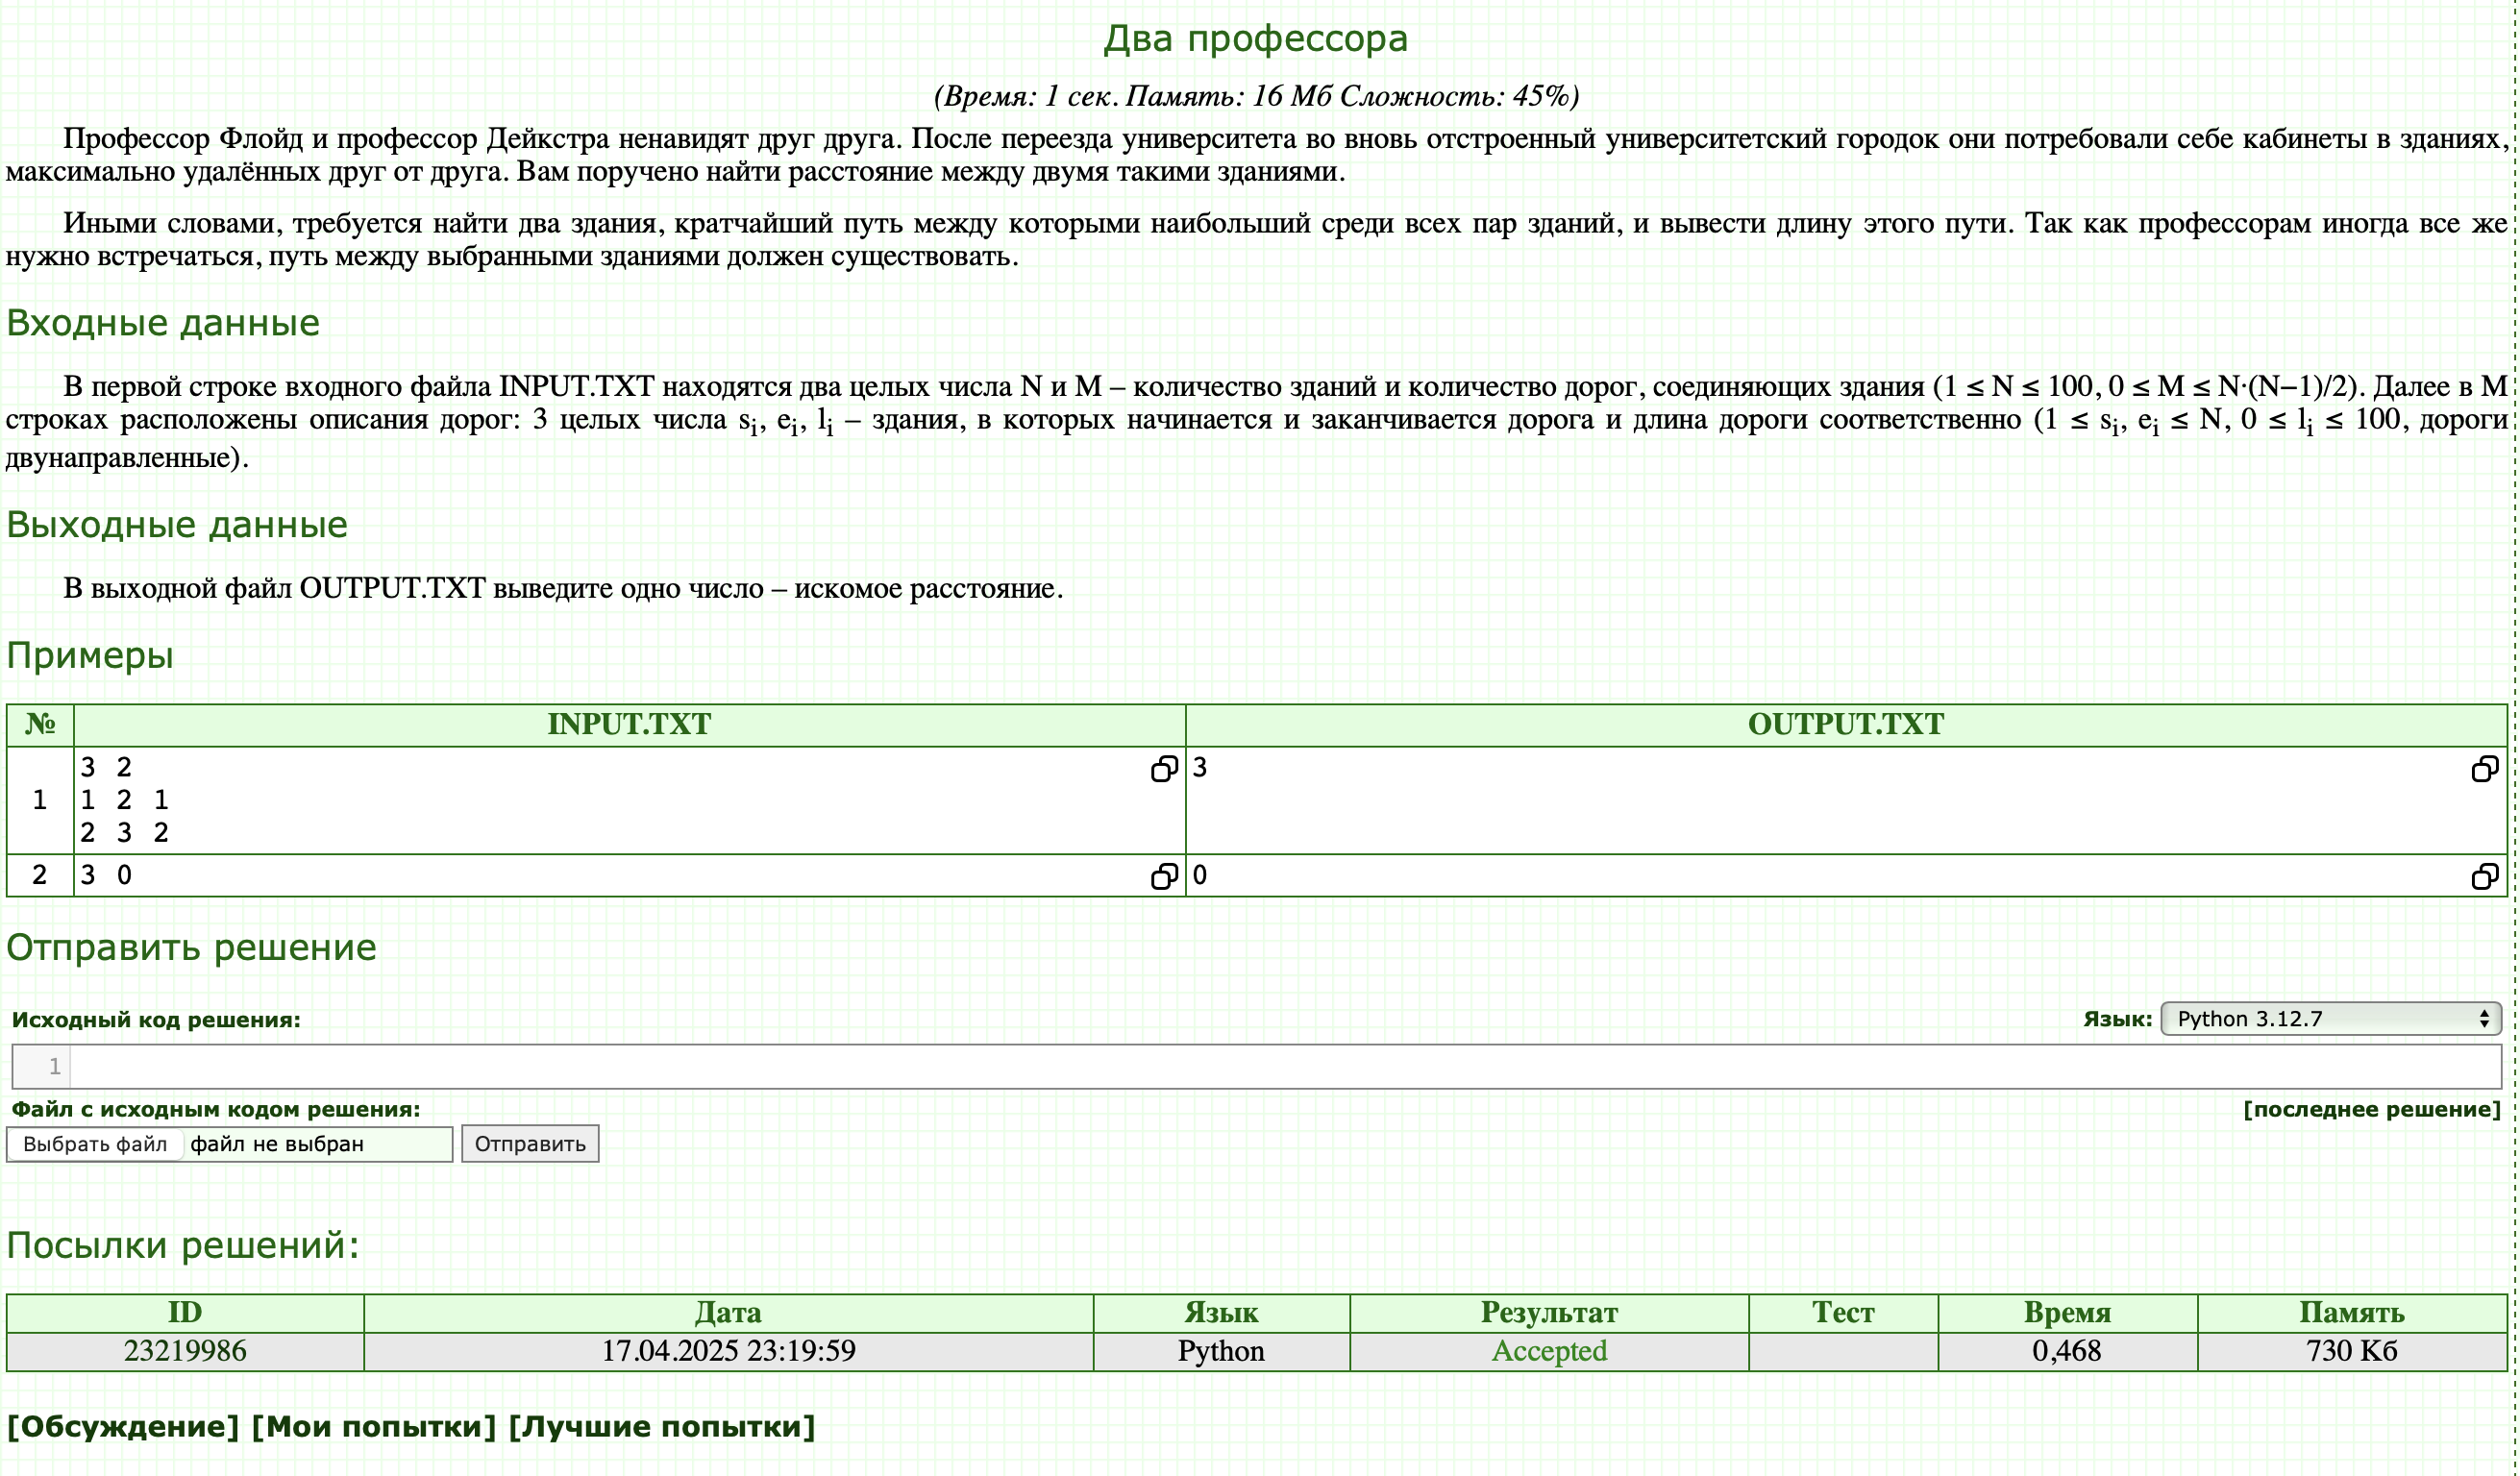

## Задача: заправки ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=32&id_topic=54&id_problem=675)) [1 балл]

В стране находится **N** городов, некоторые из которых соединены двусторонними дорогами. Чтобы проехать по одной дороге, требуется потратить **один бак бензина**. В каждом городе бензин стоит по-разному. Необходимо доехать из **первого города** в **N-ый**, потратив как можно **меньше денег** на заправки.

---

## Входные данные

- В первой строке входного файла `INPUT.TXT` задано число **N** (1 ≤ N ≤ 100) — количество городов.
- Во второй строке содержится **N** целых чисел: i-е число обозначает стоимость одного бака бензина в i-ом городе (0 ≤ стоимость ≤ 100).
- В третьей строке указано число **M** — количество дорог.
- Далее следуют **M** строк, каждая из которых содержит два целых числа — номера городов, которые соединены дорогой (дороги двусторонние, самопетель нет, между каждой парой не более одной дороги).

---

## Выходные данные

Выведите в файл `OUTPUT.TXT` одно целое число — минимально возможную суммарную стоимость поездки из первого города в N-ый. Если добраться невозможно — выведите `-1`.

---

## Пример

### Пример 1

**Входные данные:**
```
4
1 10 2 15
4
1 2
1 3
4 2
4 3
```

**Выходные данные:**
```
3
```

In [ ]:
# Асимптотическая сложность по времени — O(M log N)
# Асимптотическая сложность по памяти — O(N + M)

import heapq

n = int(input())
fuel = list(map(int, input().split()))
m = int(input())

graph = [[] for _ in range(n)]
for _ in range(m):
    u, v = map(int, input().split())
    u -= 1
    v -= 1
    graph[u].append(v)
    graph[v].append(u)

# Дейкстра: (стоимость, вершина)
dist = [float('inf')] * n
dist[0] = 0
pq = [(0, 0)]  # (total_cost, city)

while pq:
    cost, u = heapq.heappop(pq)
    if cost > dist[u]:
        continue
    for v in graph[u]:
        new_cost = cost + fuel[u]  # платим в городе u
        if new_cost < dist[v]:
            dist[v] = new_cost
            heapq.heappush(pq, (new_cost, v))

print(dist[n - 1] if dist[n - 1] != float('inf') else -1, end='')


### ВАША интуиция
Используем алгоритм Дейкстры, но, вместо фиксированных весов рёбер используем: стоимость бензина в текущем городе.

### ВАШ скрин ОКнутой задачи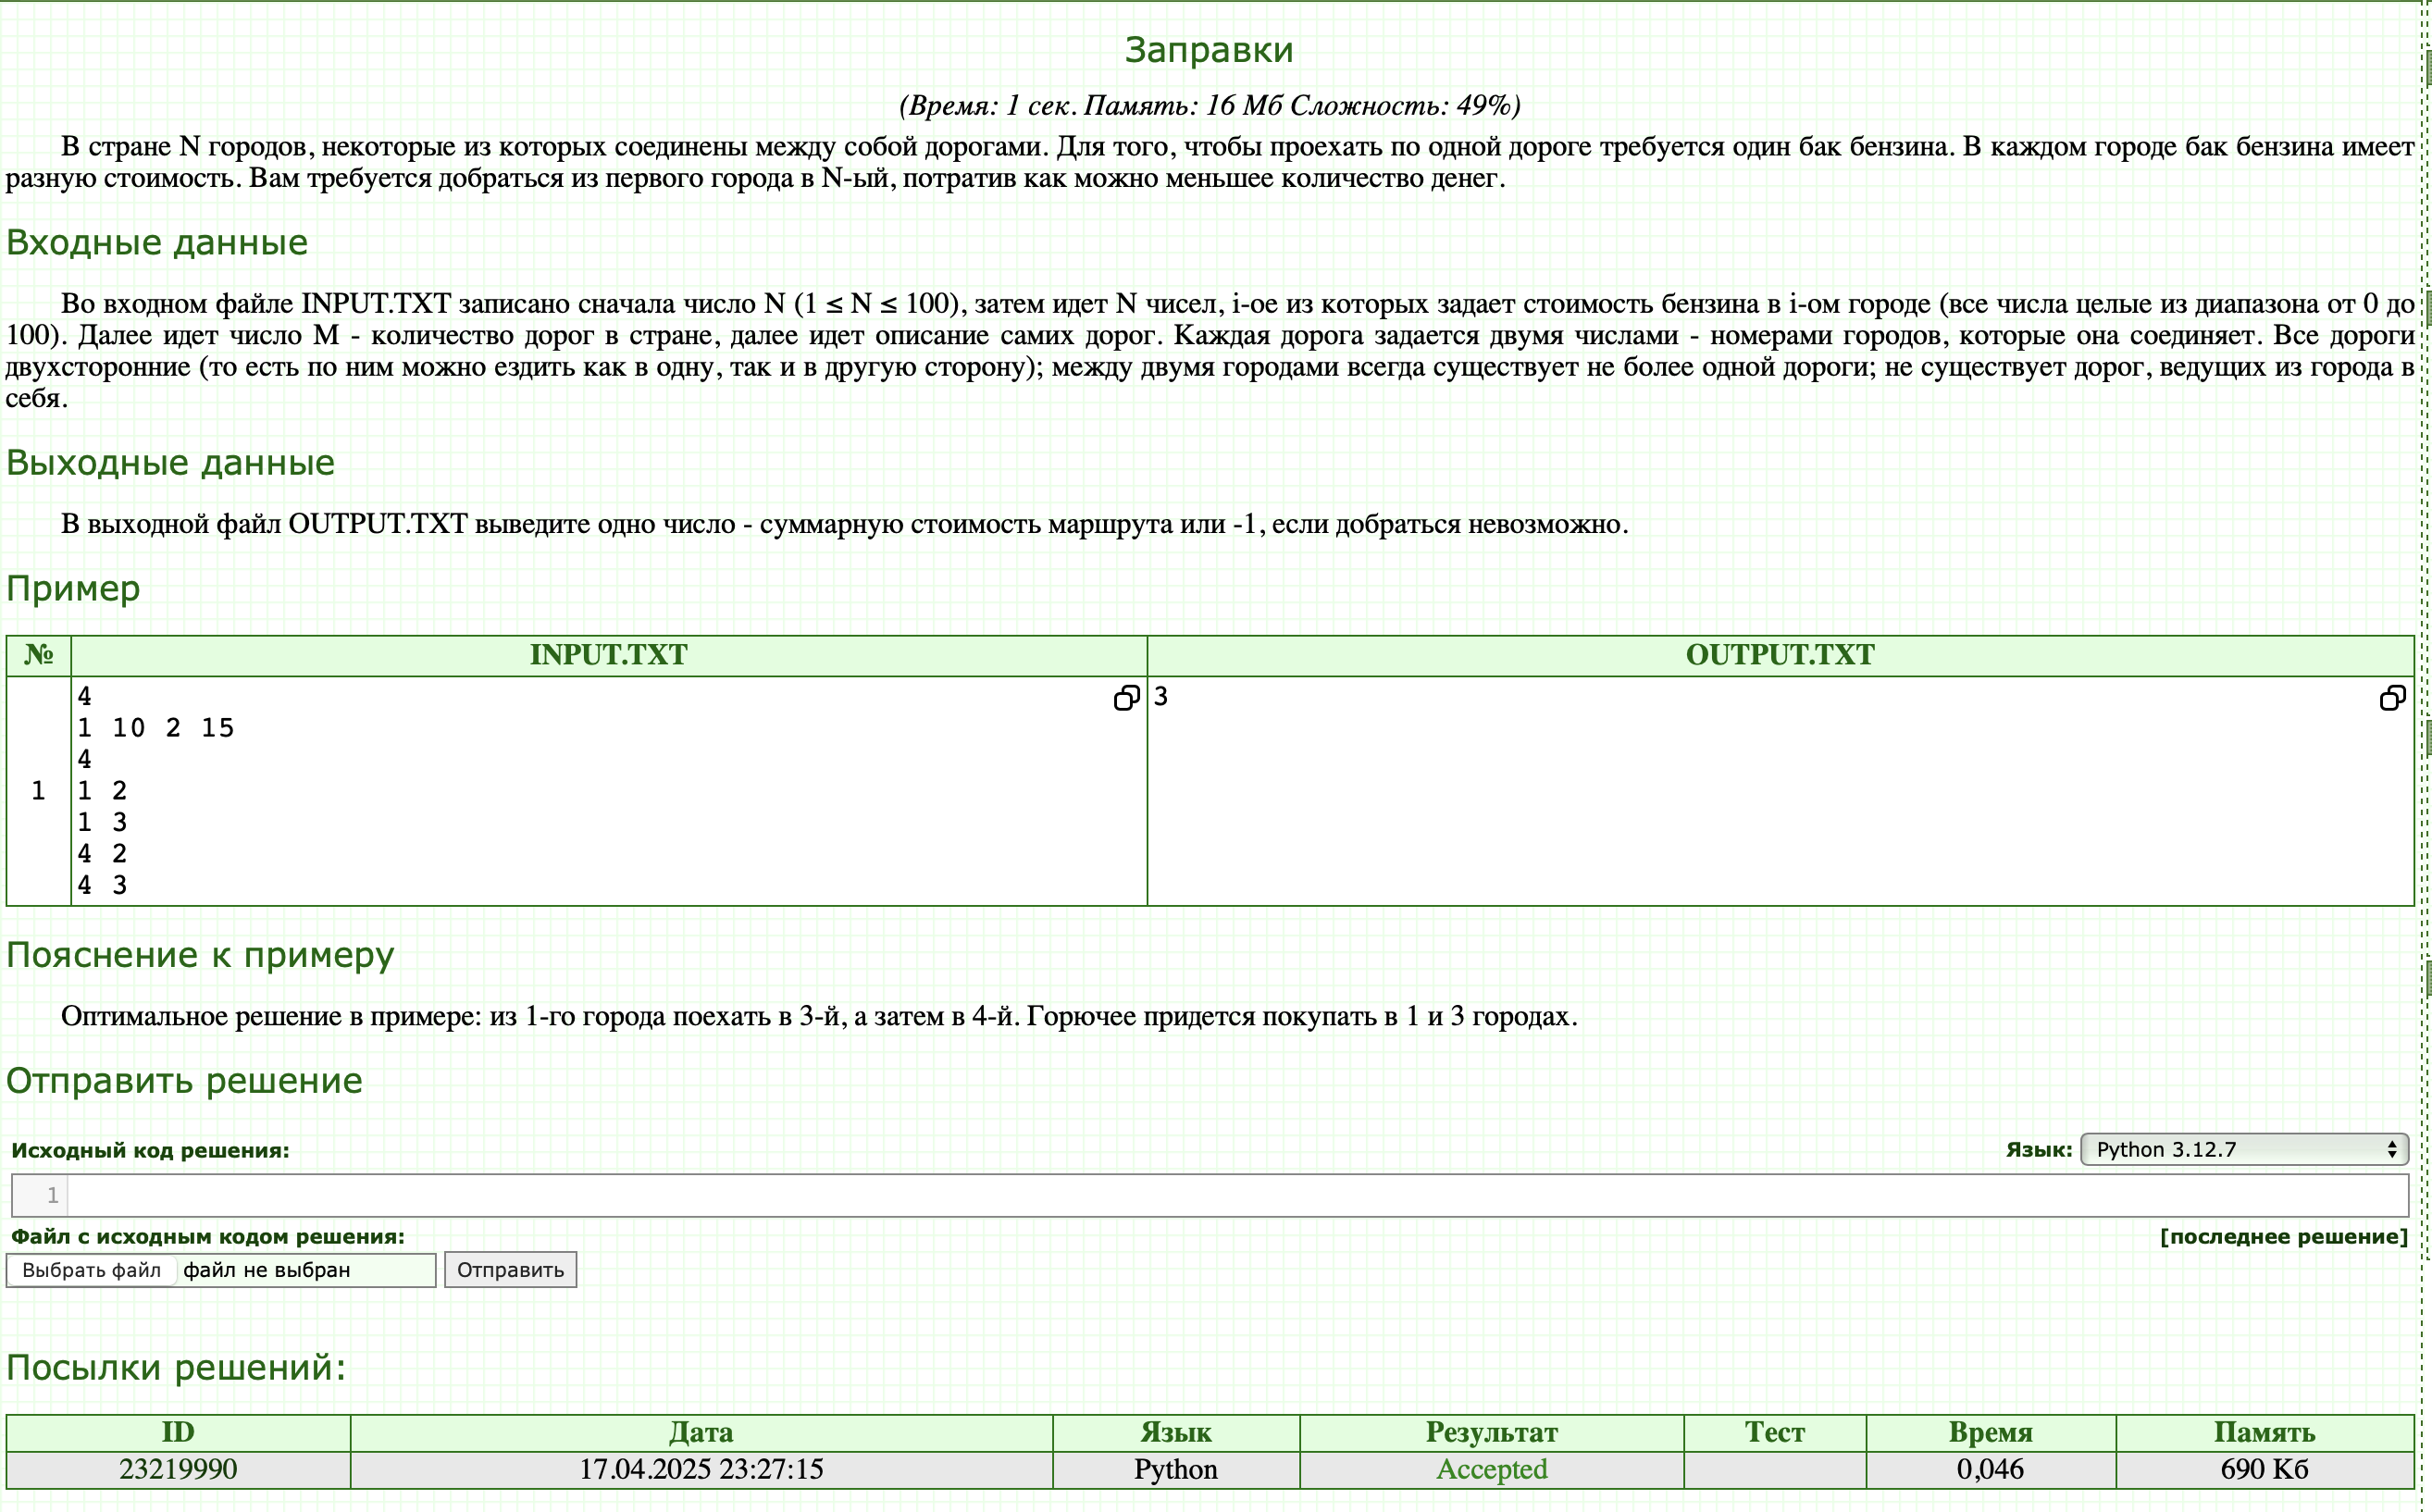

## Задача: автобусы ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=32&id_topic=54&id_problem=676)) [1 балл]

Между деревнями края Власюки курсируют автобусы, однако они ходят всего несколько раз в день. Марии Ивановне нужно как можно быстрее добраться из деревни **d** в деревню **v**, начиная путь в момент времени **0**. Каждый автобус имеет фиксированное расписание — время отправления и прибытия.

Необходимо определить минимальное возможное время, когда она сможет прибыть в деревню **v**. Если доехать невозможно — выведите `-1`.

---

## Входные данные

- В первой строке входного файла `INPUT.TXT` записано одно целое число **N** (1 ≤ N ≤ 100) — количество деревень.
- Во второй строке записаны два целых числа **d** и **v** — номера деревень, из которой и в которую нужно доехать.
- В третьей строке указано число **R** (0 ≤ R ≤ 10 000) — количество автобусных рейсов.
- Далее следует **R** строк. Каждая строка описывает рейс: четыре целых числа — деревня отправления, время отправления, деревня назначения и время прибытия (все времена — целые числа от 0 до 10 000). Из деревни можно уехать в любой момент, начиная с момента прибытия.

---

## Выходные данные

Выведите в файл `OUTPUT.TXT` одно число — минимальное время, в которое можно добраться из деревни **d** в деревню **v**, либо `-1`, если это невозможно.

---

## Пример

### Пример 1

**Входные данные:**
```
3
1 3
4
1 0 2 5
1 1 2 3
2 3 3 5
1 1 3 10
```

**Выходные данные:**
```
5
```

In [ ]:
# Асимптотическая сложность по времени — O(R log R)
# Асимптотическая сложность по памяти — O(R + N)


import heapq
from collections import defaultdict

n = int(input())
d, v = map(int, input().split())
r = int(input())

d -= 1
v -= 1

# Граф: для каждой деревни — список рейсов (departure_time, arrival_time, destination)
buses = defaultdict(list)
for _ in range(r):
    fr, dep, to, arr = map(int, input().split())
    fr -= 1
    to -= 1
    buses[fr].append((dep, arr, to))

# Массив минимальных времен прибытия
earliest = [float('inf')] * n
earliest[d] = 0


heap = [(0, d)]

while heap:
    curr_time, u = heapq.heappop(heap)
    if curr_time > earliest[u]:
        continue
    for dep_time, arr_time, to in buses[u]:
        if dep_time >= curr_time and arr_time < earliest[to]:
            earliest[to] = arr_time
            heapq.heappush(heap, (arr_time, to))

print(earliest[v] if earliest[v] != float('inf') else -1, end='')

### ВАША интуиция

Каждая вершина — деревня.

Каждое ребро — автобусный рейс, который имеет время отправления и прибытия.

Мы должны искать путь с минимальным временем прибытия из деревни d в деревню v, начиная с момента t = 0.

### ВАШ скрин ОКнутой задачи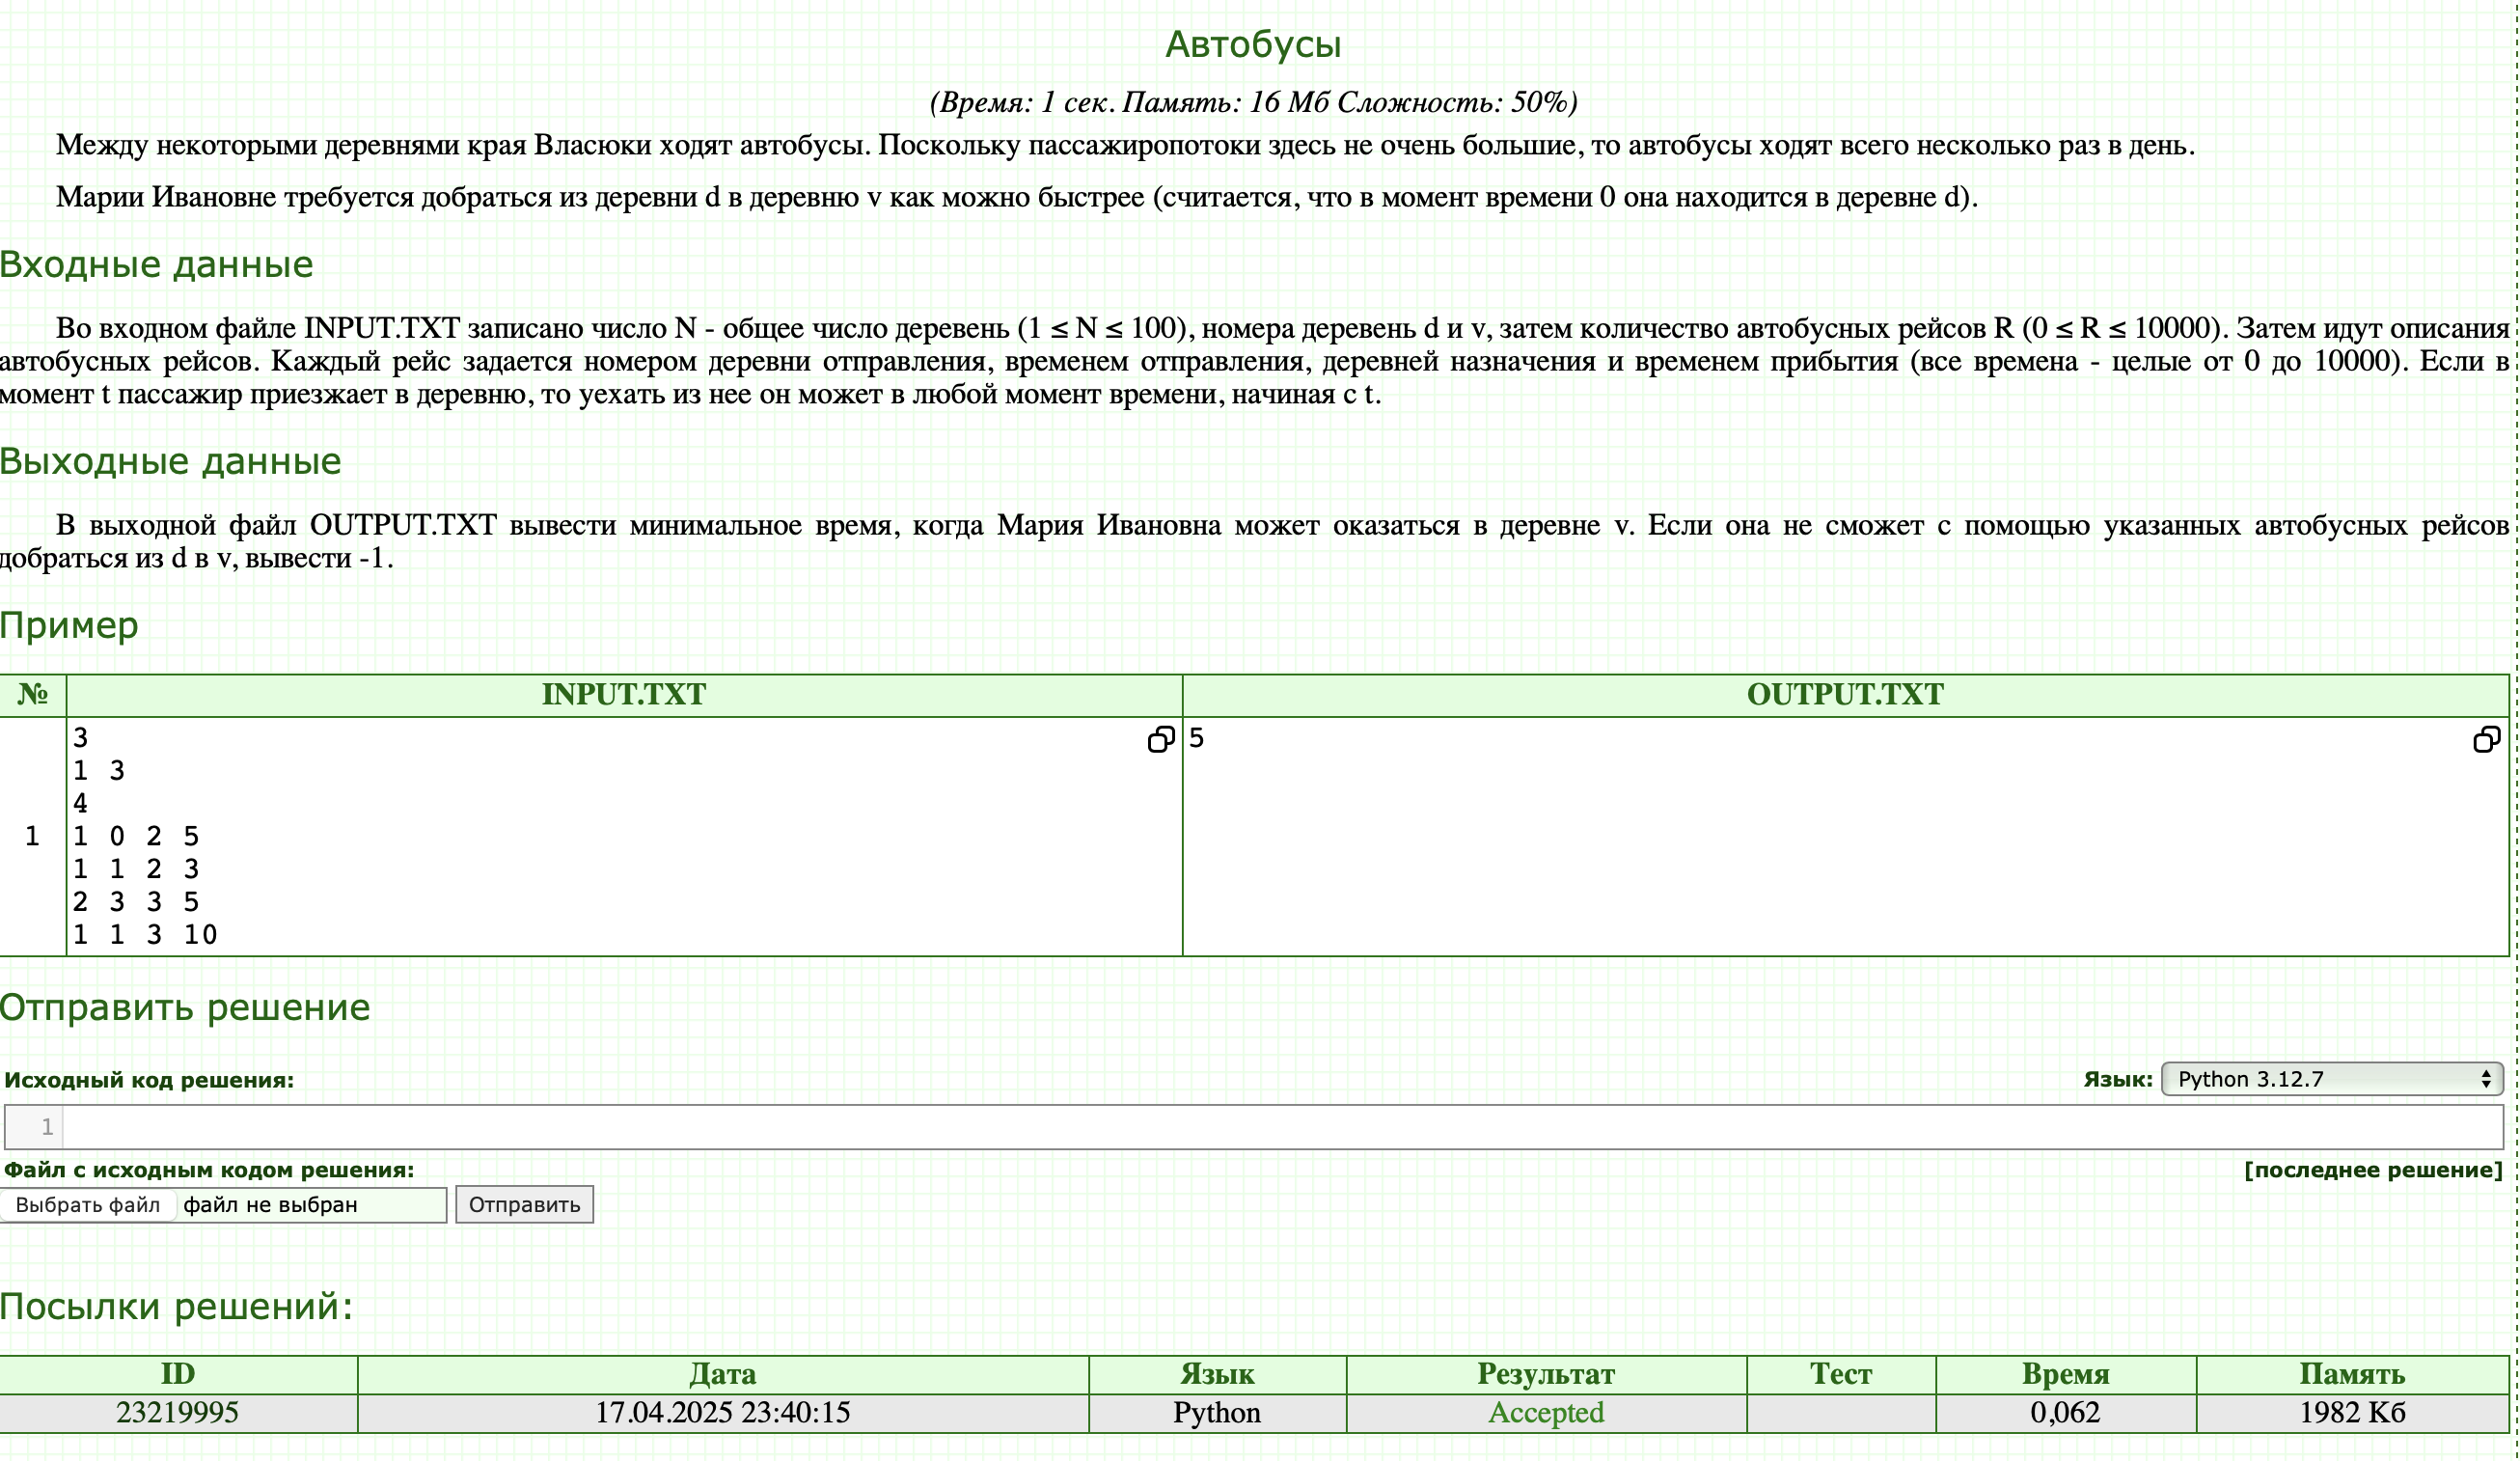

## Задача: транспортировка ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=32&id_topic=54&id_problem=1039)) [0.5 балла]

К началу Летней компьютерной школы необходимо доставить из завода (узел 1) в ЛКШ (узел N) как можно больше кружек за один рейс грузовика. Однако маршруты между пунктами имеют ограничения: у каждой дороги указано **время проезда** и **максимальный допустимый вес автомобиля**. Всего на транспортировку есть не более 24 часов.

Известно:
- Пустой грузовик весит **3 тонны (3 000 000 грамм)**;
- Одна кружка весит **100 грамм**;
- Нужно доставить **максимально возможное количество кружек**, не превышая ограничений дорог и времени.

---

## Входные данные

- В первой строке входного файла `INPUT.TXT` записаны два целых числа **N** и **M** — количество узлов дорожной схемы и количество дорог соответственно (1 ≤ N ≤ 500).
- Далее следуют **M** строк, каждая содержит описание одной дороги: четыре целых числа — номера узловых пунктов, которые она соединяет (**u**, **v**), **время проезда** (в минутах, ≤ 1440), и **максимальный допустимый вес** автомобиля (в граммах, ≤ 10^9).
- Все дороги **двусторонние**, между одной парой узлов не более одной дороги, самопетель нет.

---

## Выходные данные

Выведите в файл `OUTPUT.TXT` одно число — **максимальное количество кружек**, которые можно доставить из узла 1 в узел N **за время не более 24 часов (1440 минут)** и **не превышая ограничений по весу на дорогах**.

---

## Пример

### Пример 1

**Входные данные:**
```
3 3
1 2 10 3000220
2 3 20 3000201
1 3 1 3000099
```

**Выходные данные:**
```
2
```

In [ ]:
# Асимптотическая сложность по времени — O(M log N)
# Асимптотическая сложность по памяти — O(N + M)


import heapq
import sys


input = sys.stdin.read
data = input().split()

n, m = int(data[0]), int(data[1])
edges = []
index = 2

for _ in range(m):
    u = int(data[index]) - 1
    v = int(data[index + 1]) - 1
    time = int(data[index + 2])
    limit = int(data[index + 3])
    edges.append((u, v, time, limit))
    index += 4

def can_deliver(k):
    max_weight = 3000000 + 100 * k
    graph = [[] for _ in range(n)]
    for u, v, t, w in edges:
        if w >= max_weight:
            graph[u].append((v, t))
            graph[v].append((u, t))

    dist = [float('inf')] * n
    dist[0] = 0
    pq = [(0, 0)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, t in graph[u]:
            if dist[v] > dist[u] + t:
                dist[v] = dist[u] + t
                heapq.heappush(pq, (dist[v], v))
    return dist[n - 1] <= 1440

# Бинарный поиск по числу кружек
low = 0
high = 10000000
answer = 0

while low <= high:
    mid = (low + high) // 2
    if can_deliver(mid):
        answer = mid
        low = mid + 1
    else:
        high = mid - 1

print(answer, end='')

### ВАША интуиция

Вес пустой машины: 3000000 г

Вес каждой кружки: 100 г

Цель: найти максимальное x, чтобы грузовик весом 3000000 + 100 * x мог добраться из узла 1 до узла N за ≤ 1440 минут, по дорогам, где пропускают такой вес.

Это поиск максимального груза, при котором существует путь за ≤ 1440 минут.

### ВАШ скрин ОКнутой задачи
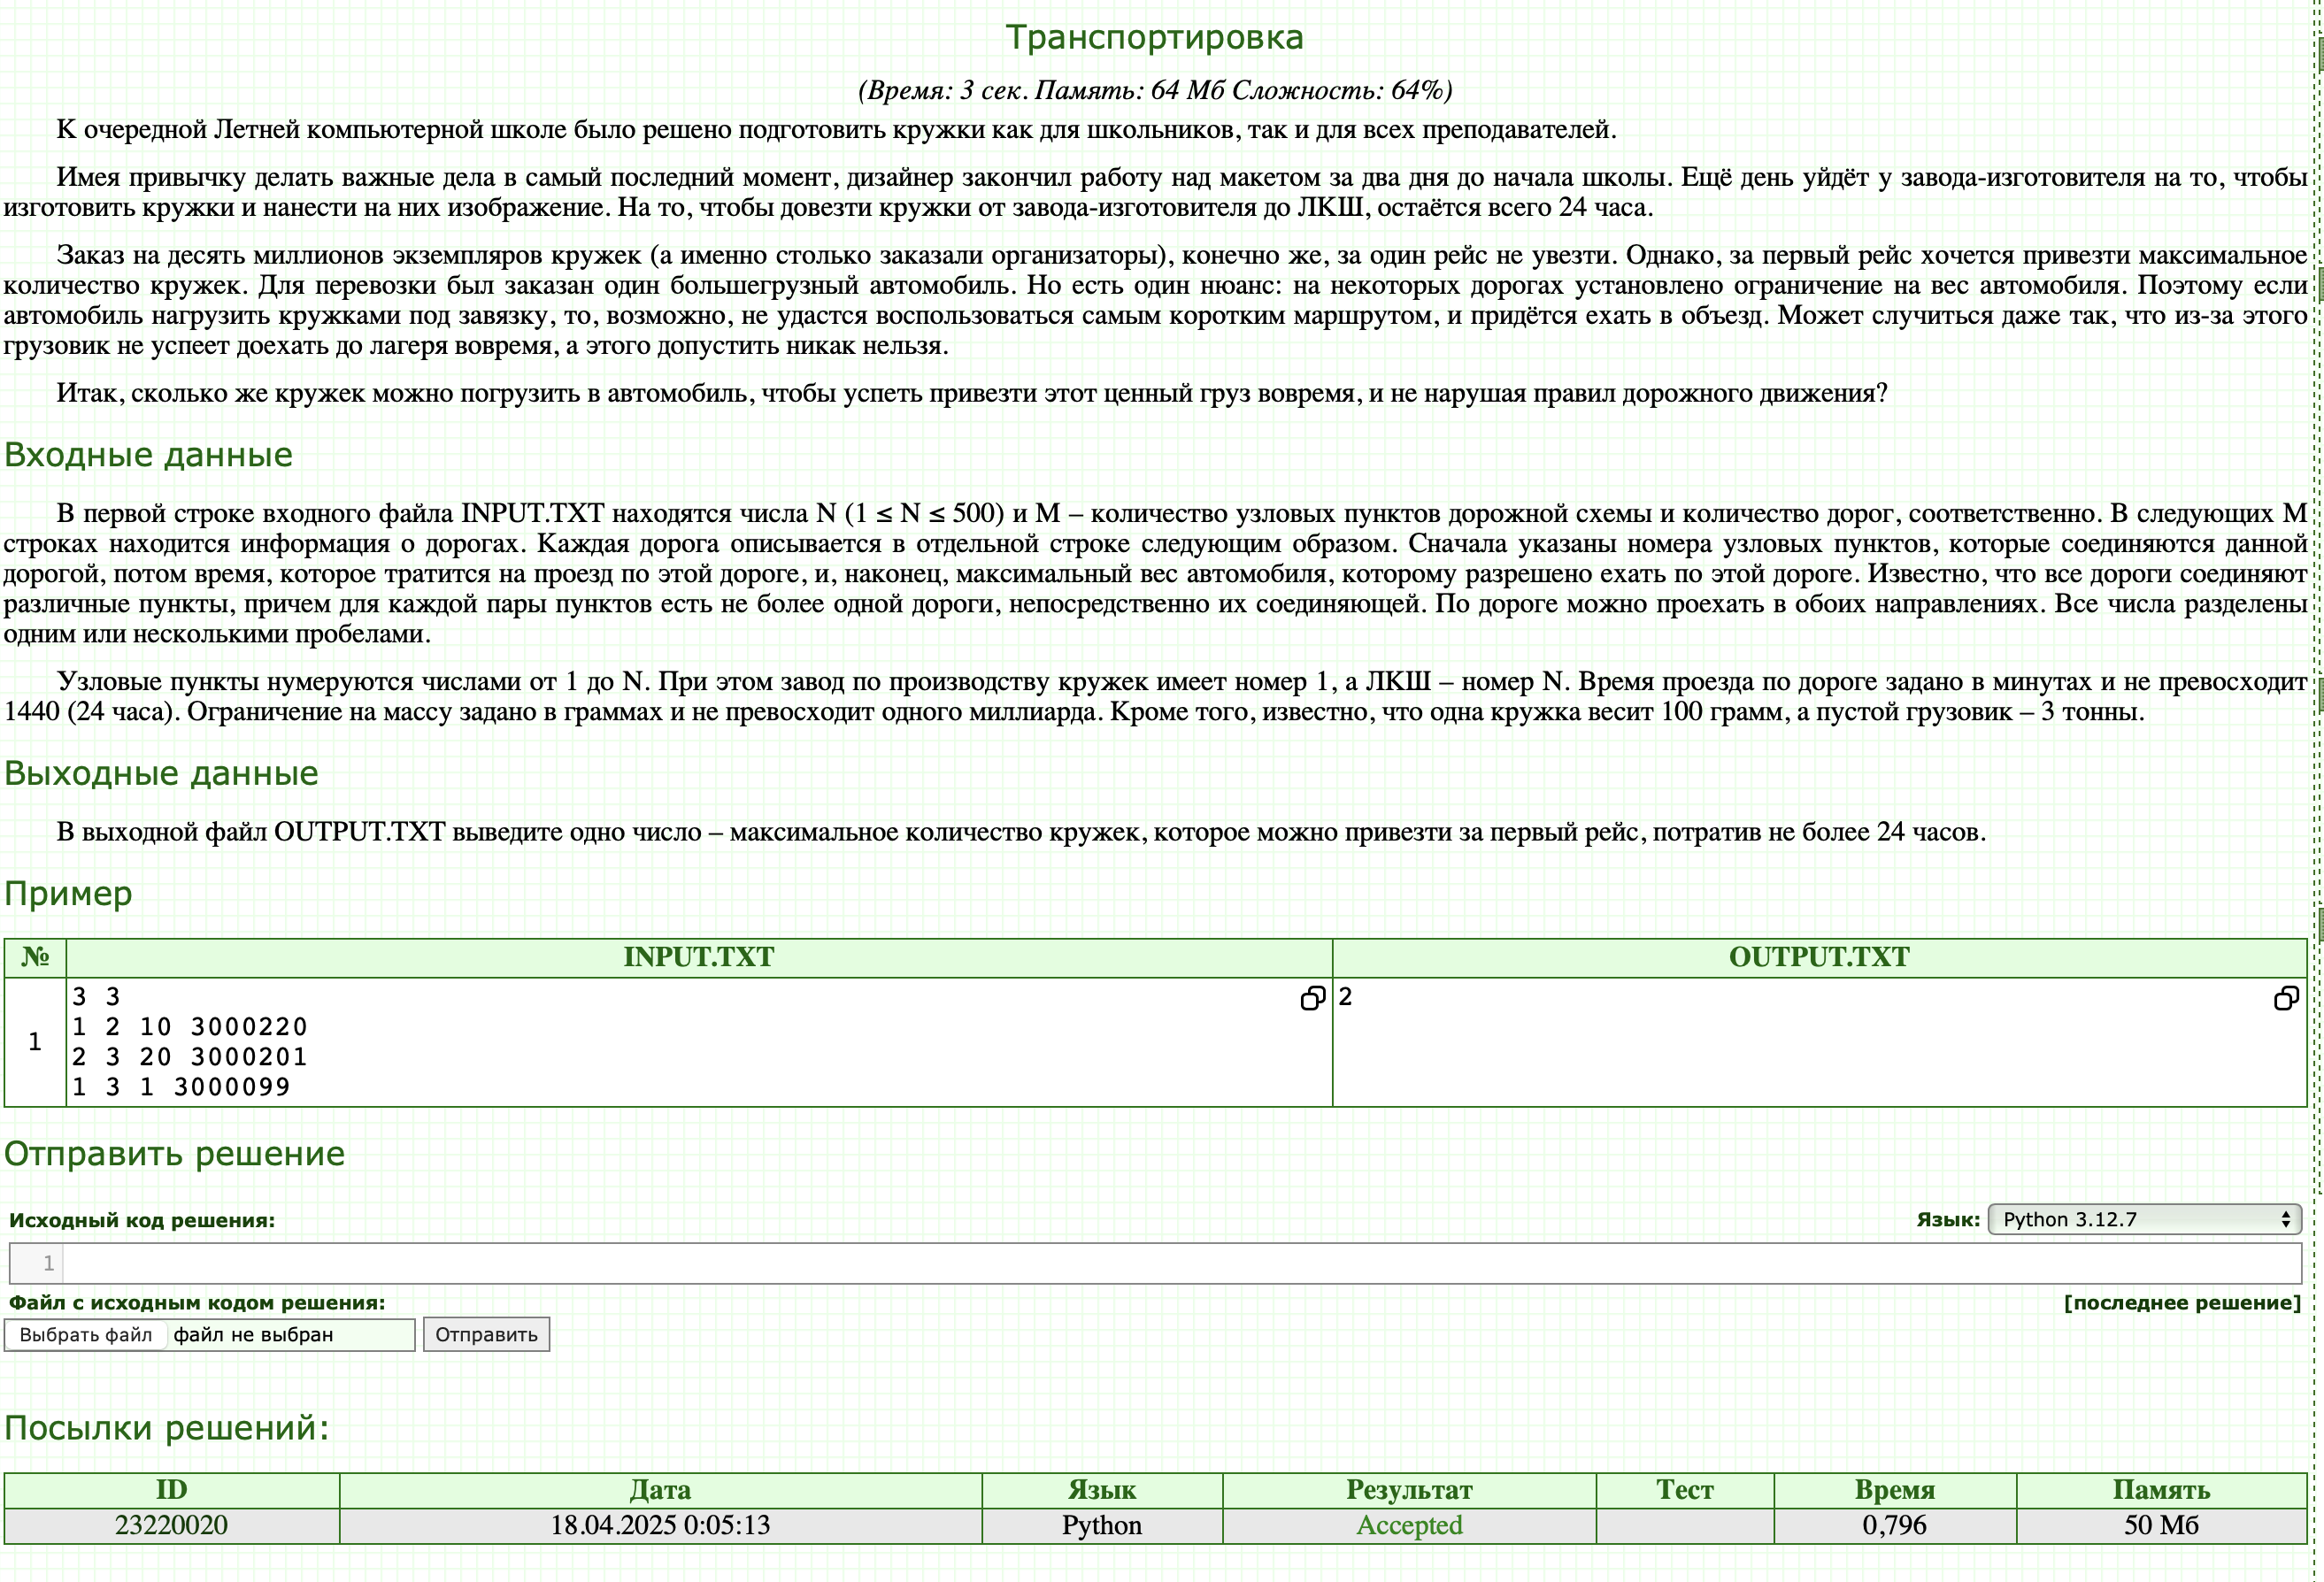